Question 2
Generate Make-Moons dataset without using sklearn make_moons. Use default noise 0.2, also create two extra test sets with noise 0.1 and 0.3 for robustness reporting. Make training set and test set with 500 points each. Standardize x after the split using train statistics only. Create a validation split of the train set with 20 percent for model selection. Use random seed 1337.
Train the following models:
1. MLP with hidden layer - early stopping (patience=50)
2. MLP with L1 regularization . L1 gird λ ∈ {1e−6, 3e−6, 1e−5, 3e−5, 1e−4, 3e−4}. Report layerwise sparsity and validation AUROC vs.  λ
3. MLP with L2 regularization (you may vary the penalty coefficient by choose the best one using a validation dataset)
4. Logistic regression with polynomial features (x₁x₂, x₁², etc.)


 Evaluation and Analysis 
• Evaluate test accuracy on noise = 0.20, and robustness accuracy on 0.10 & 0.30.
• Create a table with test accuracy for the four models on the three test noise levels. Include parameter count.
• Plot decision boundaries side by side for all 4 models with default noise 0.2.
• Discuss:
	- Effect of L1 on sparsity and boundary jaggedness
	- Effect of L2 on smoothness and margin
• Add class imbalance (70:30) in the trainset while keeping the testset balanced. Report accuracy and AUROC and discuss the effect of imbalance.


In [5]:
pip install tenserflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tenserflow (from versions: none)

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tenserflow


In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.metrics import AUC

import matplotlib.pyplot as plt

np.random.seed(1337)
tf.random.set_seed(1337)

In [ ]:
def make_moons(n_samples=500, noise=0.2):
    n_half = n_samples // 2
    theta = np.linspace(0, np.pi, n_half)

    # First moon
    x1 = np.cos(theta)
    y1 = np.sin(theta)
    labels1 = np.zeros(n_half)

    # Second moon
    x2 = 1 - np.cos(theta)
    y2 = 0.5 - np.sin(theta)
    labels2 = np.ones(n_half)
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.concatenate([labels1, labels2])
    X += np.random.normal(0, noise, X.shape)

    return X, y

#Generate Data
X_train, y_train = make_moons()
X_test, y_test = make_moons()
X_test_low, y_test_low = make_moons(noise=0.1)
X_test_high, y_test_high = make_moons(noise=0.3)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1337)

# Standardize X after the split using train statistics only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std
X_test_low = (X_test_low - mean) / std
X_test_high = (X_test_high - mean) / std

print("Training data shape after split:", X_train.shape, y_train.shape)
print("Validation data shape:", X_val.shape, y_val.shape)

Training data shape after split: (400, 2) (400,)
Validation data shape: (100, 2) (100,)


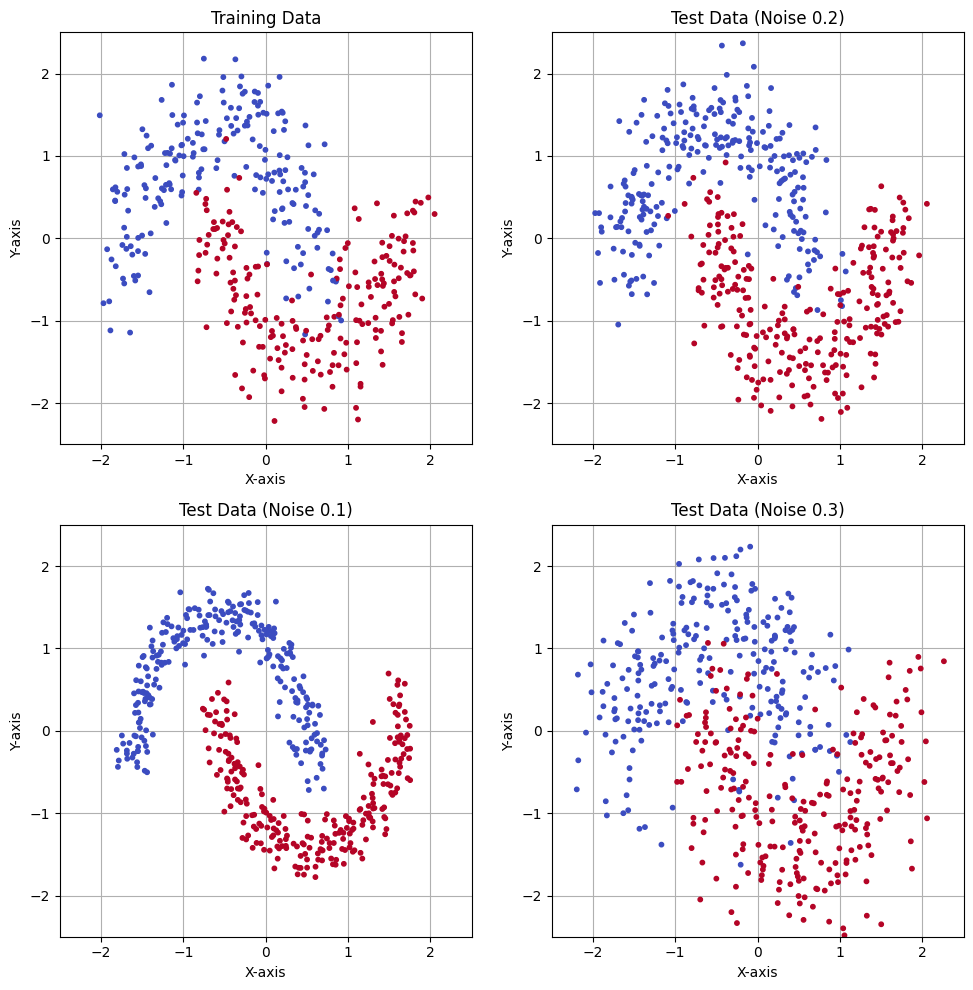

In [9]:
# Visualize the dataset
x_min, x_max = -2.5, 2.5
y_min, y_max = -2.5, 2.5

plt.figure(figsize=(10, 10))

# Visualize the training data
plt.subplot(2, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=10, zorder=2)
plt.title('Training Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, zorder=1)

# Visualize the test data (Noise 0.2)
plt.subplot(2, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=10, zorder=2)
plt.title('Test Data (Noise 0.2)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, zorder=1)

# Visualize the test data with low noise (Noise 0.1)
plt.subplot(2, 2, 3)
plt.scatter(X_test_low[:, 0], X_test_low[:, 1], c=y_test_low, cmap='coolwarm', s=10, zorder=2)
plt.title('Test Data (Noise 0.1)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, zorder=1)

# Visualize the test data with high noise (Noise 0.3)
plt.subplot(2, 2, 4)
plt.scatter(X_test_high[:, 0], X_test_high[:, 1], c=y_test_high, cmap='coolwarm', s=10, zorder=2)
plt.title('Test Data (Noise 0.3)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, zorder=1)

plt.tight_layout()
plt.show()

In [10]:
def plot_decision_boundaries(model,
                                X_test, y_test,
                                X_test_low, y_test_low,
                                X_test_high, y_test_high,
                                poly_transformer=None,
                                margin=0.5, grid_size=200,
                                figsize=(15, 5)):

    # Determine overall plotting range using the original X_test data
    all_test_X_original = np.vstack([X_test[:, :2], X_test_low[:, :2], X_test_high[:, :2]])
    overall_min, overall_max = np.min(all_test_X_original), np.max(all_test_X_original)
    x_min, x_max = overall_min - margin, overall_max + margin
    y_min, y_max = overall_min - margin, overall_max + margin

    # Create meshgrid for prediction
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_size),
                            np.linspace(y_min, y_max, grid_size))

    # Transform meshgrid points if a polynomial transformer is provided
    if poly_transformer:
        meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
        meshgrid_points_poly = poly_transformer.transform(meshgrid_points)
        Z = model.predict(meshgrid_points_poly, verbose=0)
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=figsize)

    plt.subplot(1, 3, 1)
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.6, levels=np.linspace(0, 1, 11))
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=20, edgecolors='k', label='Noise 0.2')
    plt.title('Decision Boundary (Noise 0.2)')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.6, levels=np.linspace(0, 1, 11))
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter(X_test_low[:, 0], X_test_low[:, 1], c=y_test_low, cmap='coolwarm', s=20, edgecolors='k', marker='^', label='Noise 0.1')
    plt.title('Decision Boundary (Noise 0.1)')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.6, levels=np.linspace(0, 1, 11))
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter(X_test_high[:, 0], X_test_high[:, 1], c=y_test_high, cmap='coolwarm', s=20, edgecolors='k', marker='s', label='Noise 0.3')
    plt.title('Decision Boundary (Noise 0.3)')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
def evaluate_model(model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high, label="Model", poly_transformer=None):

    # Transform test data if a polynomial transformer is provided
    if poly_transformer:
        X_test = poly_transformer.transform(X_test)
        X_test_low = poly_transformer.transform(X_test_low)
        X_test_high = poly_transformer.transform(X_test_high)

    test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test, verbose=0)
    test_low_loss, test_low_acc, test_low_auc = model.evaluate(X_test_low, y_test_low, verbose=0)
    test_high_loss, test_high_acc, test_high_auc = model.evaluate(X_test_high, y_test_high, verbose=0)

    print(f"\n{label} Performance:")
    print(f"Test Data (Noise 0.2) - Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, AUROC: {test_auc:.4f}")
    print(f"Test Data (Noise 0.1) - Loss: {test_low_loss:.4f}, Accuracy: {test_low_acc:.4f}, AUROC: {test_low_auc:.4f}")
    print(f"Test Data (Noise 0.3) - Loss: {test_high_loss:.4f}, Accuracy: {test_high_acc:.4f}, AUROC: {test_high_auc:.4f}")

In [12]:
def get_model_metrics(model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high, poly_transformer=None):

    # Transform test data if a polynomial transformer is provided
    if poly_transformer:
        X_test = poly_transformer.transform(X_test)
        X_test_low = poly_transformer.transform(X_test_low)
        X_test_high = poly_transformer.transform(X_test_high)
    
    _, acc_02, _ = model.evaluate(X_test, y_test, verbose=0)
    _, acc_01, _ = model.evaluate(X_test_low, y_test_low, verbose=0)
    _, acc_03, _ = model.evaluate(X_test_high, y_test_high, verbose=0)
    
    param_count = model.count_params()
    
    return acc_02, acc_01, acc_03, param_count

# **1. Model 1: MLP (No Regularization)**

In [13]:
mlp_model = Sequential([
    Input(shape=(2,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy', AUC(name='auc')])

early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)

print(f"Training model!")
history = mlp_model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
print(f"Model trained for {len(history.epoch)} epochs.")

Training model!
Model trained for 140 epochs.


## **Testing the Model**

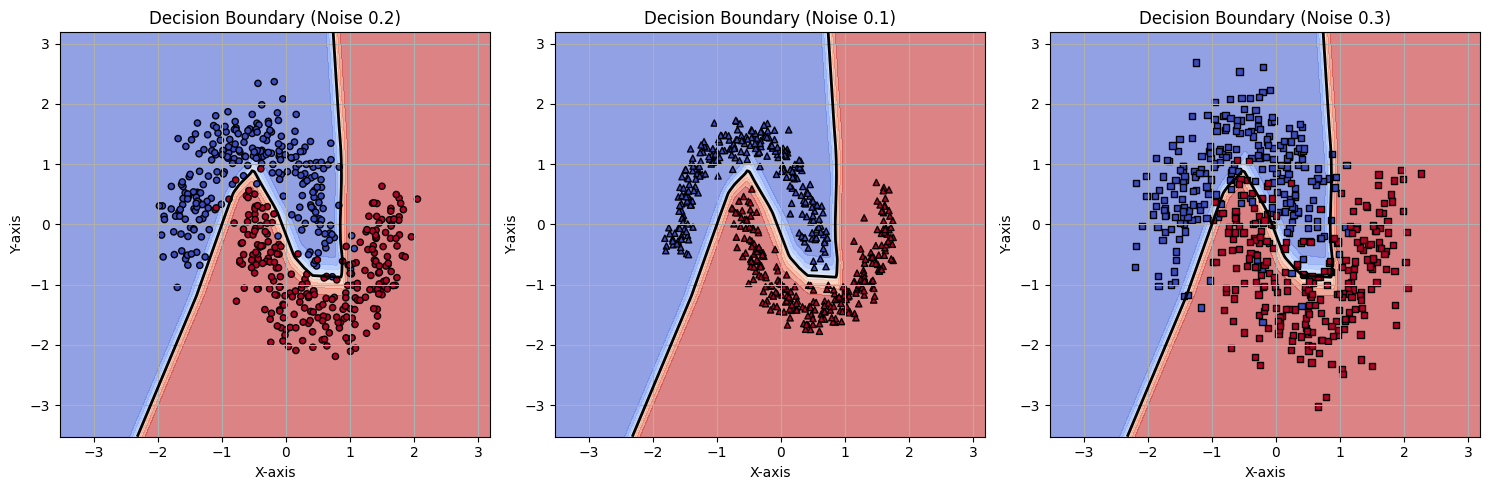


MLP (No Regularization) Performance:
Test Data (Noise 0.2) - Loss: 0.0870, Accuracy: 0.9740, AUROC: 0.9946
Test Data (Noise 0.1) - Loss: 0.0138, Accuracy: 1.0000, AUROC: 1.0000
Test Data (Noise 0.3) - Loss: 0.3121, Accuracy: 0.8940, AUROC: 0.9592


In [14]:
plot_decision_boundaries(mlp_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high)
evaluate_model(mlp_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high, "MLP (No Regularization)")

# **2. Model 2: MLP (L1 Regularization)**

## **Training and Validating the Model**

In [15]:
lambda_values = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
l1_val_auroc_scores = []
layer_sparsity = []
l1_models = []

for lambda_value in lambda_values:
    print(f"Training with lambda (L1): {lambda_value}")

    model = Sequential([
        Input(shape=(2,)),
        Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=lambda_value)),
        Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=lambda_value))
    ])

    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy', AUC(name='auc')])

    early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)

    history = model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)

    print(f"Model trained for {len(history.epoch)} epochs.")

    # Evaluate the model on the validation set
    loss, accuracy, val_auc = model.evaluate(X_val, y_val, verbose=0)
    l1_val_auroc_scores.append(val_auc)
    l1_models.append(model)

    # Calculate layer-wise sparsity
    sparsity_for_lambda = []
    for layer in model.layers:
        if isinstance(layer, Dense):
            weights = layer.get_weights()
            if len(weights) > 0:
                weight_matrix = weights[0]
                # Check for weights close to zero
                zero_weights = np.sum(np.isclose(weight_matrix, 0, atol=1e-3))
                total_weights = weight_matrix.size
                sparsity = (zero_weights / total_weights) * 100
                sparsity_for_lambda.append(sparsity)
            else:
                sparsity_for_lambda.append(0)

    layer_sparsity.append(sparsity_for_lambda)

print("Validation AUROC scores (L1):", l1_val_auroc_scores)
print("Layer-wise sparsity (L1):", layer_sparsity)

# Find the best lambda for L1 based on validation AUROC
best_l1_lambda_index = np.argmax(l1_val_auroc_scores)
best_l1_lambda = lambda_values[best_l1_lambda_index]
best_l1_model = l1_models[best_l1_lambda_index]

print(f"\nBest L1 lambda: {best_l1_lambda} with Validation AUROC: {l1_val_auroc_scores[best_l1_lambda_index]:.4f}")

Training with lambda (L1): 1e-06
Model trained for 115 epochs.
Training with lambda (L1): 3e-06
Model trained for 97 epochs.
Training with lambda (L1): 1e-05
Model trained for 103 epochs.
Training with lambda (L1): 3e-05
Model trained for 116 epochs.
Training with lambda (L1): 0.0001
Model trained for 113 epochs.
Training with lambda (L1): 0.0003
Model trained for 104 epochs.
Validation AUROC scores (L1): [0.9925522804260254, 0.990338146686554, 0.9941625595092773, 0.9925523400306702, 0.9937599897384644, 0.9929548501968384]
Layer-wise sparsity (L1): [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [7.8125, 3.125], [9.375, 3.125], [12.5, 9.375]]

Best L1 lambda: 1e-05 with Validation AUROC: 0.9942


## **Validation and Regularization Results**

In [16]:
for i, lambda_value in enumerate(lambda_values):
    print(f"Lambda (L1): {lambda_value}")
    print(f"Validation AUROC (L1): {l1_val_auroc_scores[i]:.4f}")
    print("Layer-wise sparsity (L1):")
    for j, sparsity in enumerate(layer_sparsity[i]):
        print(f"  Dense layer {j+1} sparsity: {sparsity:.2f}%")
    print("-" * 20)

Lambda (L1): 1e-06
Validation AUROC (L1): 0.9926
Layer-wise sparsity (L1):
  Dense layer 1 sparsity: 0.00%
  Dense layer 2 sparsity: 0.00%
--------------------
Lambda (L1): 3e-06
Validation AUROC (L1): 0.9903
Layer-wise sparsity (L1):
  Dense layer 1 sparsity: 0.00%
  Dense layer 2 sparsity: 0.00%
--------------------
Lambda (L1): 1e-05
Validation AUROC (L1): 0.9942
Layer-wise sparsity (L1):
  Dense layer 1 sparsity: 0.00%
  Dense layer 2 sparsity: 0.00%
--------------------
Lambda (L1): 3e-05
Validation AUROC (L1): 0.9926
Layer-wise sparsity (L1):
  Dense layer 1 sparsity: 7.81%
  Dense layer 2 sparsity: 3.12%
--------------------
Lambda (L1): 0.0001
Validation AUROC (L1): 0.9938
Layer-wise sparsity (L1):
  Dense layer 1 sparsity: 9.38%
  Dense layer 2 sparsity: 3.12%
--------------------
Lambda (L1): 0.0003
Validation AUROC (L1): 0.9930
Layer-wise sparsity (L1):
  Dense layer 1 sparsity: 12.50%
  Dense layer 2 sparsity: 9.38%
--------------------


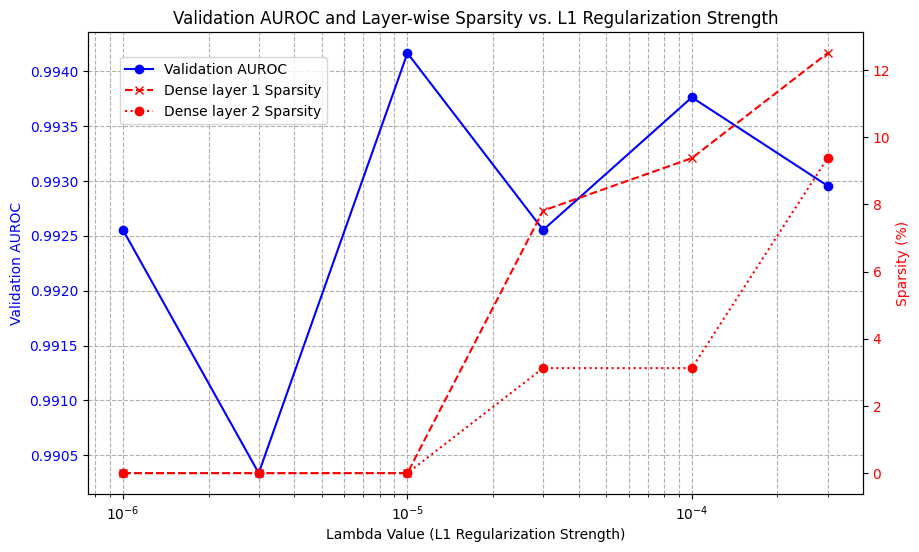

In [17]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot AUROC on the first y-axis
ax1.semilogx(lambda_values, l1_val_auroc_scores, marker='o', color='blue', label='Validation AUROC')
ax1.set_xlabel("Lambda Value (L1 Regularization Strength)")
ax1.set_ylabel("Validation AUROC", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which="both", linestyle='--')

# Create a second y-axis for sparsity
ax2 = ax1.twinx()

# Plot layer-wise sparsity on the second y-axis with different colors
for i in range(len(layer_sparsity[0])):
    layer_sparse = [sparsity[i] for sparsity in layer_sparsity]
    ax2.semilogx(lambda_values, layer_sparse, marker=['x', 'o'][i], linestyle=['--', ':'][i], label=f'Dense layer {i+1} Sparsity', color='red')

ax2.set_ylabel("Sparsity (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a title and legend
plt.title("Validation AUROC and Layer-wise Sparsity vs. L1 Regularization Strength")
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.85))

plt.show()

## **Testing the Model**

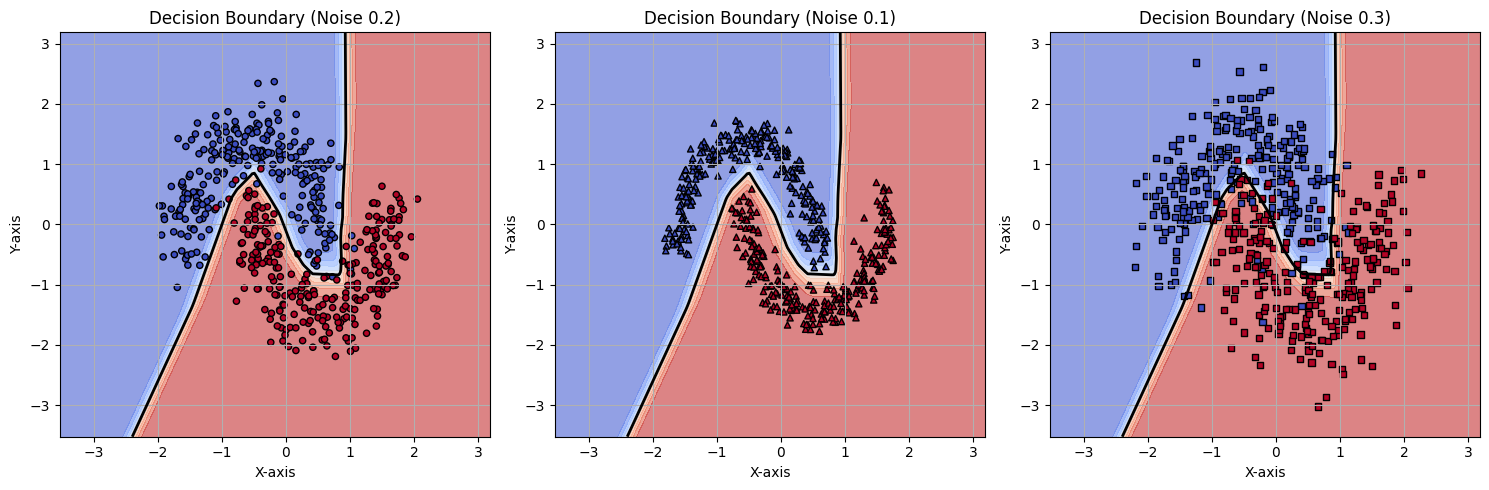


MLP (L1 Regularization) Performance:
Test Data (Noise 0.2) - Loss: 0.0804, Accuracy: 0.9740, AUROC: 0.9955
Test Data (Noise 0.1) - Loss: 0.0189, Accuracy: 1.0000, AUROC: 1.0000
Test Data (Noise 0.3) - Loss: 0.2711, Accuracy: 0.9000, AUROC: 0.9672


In [18]:
plot_decision_boundaries(best_l1_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high)
evaluate_model(best_l1_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high, "MLP (L1 Regularization)")

# **3. Model 3: MLP (L2 Regularization)**

## **Training and Validating the Model**

In [ ]:
lambda_values = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
l2_val_auroc_scores = []
l2_models = []

for lambda_value in lambda_values:
    print(f"Training with lambda (L2): {lambda_value}")

    model = Sequential([
        Input(shape=(2,)),
        Dense(32, activation='relu', kernel_regularizer=l1_l2(l2=lambda_value)),
        Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l2=lambda_value))
    ])

    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy', AUC(name='auc')])

    early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)

    history = model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)

    print(f"Model trained for {len(history.epoch)} epochs.")

    # Evaluate the model on the validation set
    loss, accuracy, val_auc = model.evaluate(X_val, y_val, verbose=0)
    l2_val_auroc_scores.append(val_auc)
    l2_models.append(model)

print("Validation AUROC scores (L2):", l2_val_auroc_scores)

# Find the best lambda for L2 based on validation AUROC
best_l2_lambda_index = np.argmax(l2_val_auroc_scores)
best_l2_lambda = lambda_values[best_l2_lambda_index]
best_l2_model = l2_models[best_l2_lambda_index]
print(f"\nBest L2 lambda: {best_l2_lambda} with Validation AUROC: {l2_val_auroc_scores[best_l2_lambda_index]:.4f}")



Training with lambda (L2): 1e-06
Model trained for 93 epochs.
Training with lambda (L2): 3e-06
Model trained for 143 epochs.
Training with lambda (L2): 1e-05
Model trained for 103 epochs.
Training with lambda (L2): 3e-05
Model trained for 119 epochs.
Training with lambda (L2): 0.0001
Model trained for 102 epochs.
Training with lambda (L2): 0.0003
Model trained for 94 epochs.
Validation AUROC scores (L2): [0.9931561350822449, 0.9937600493431091, 0.9909420013427734, 0.9923510551452637, 0.9905394315719604, 0.990338146686554]

Best L2 lambda: 3e-06 with Validation AUROC: 0.9938


## **Validation and Regularization Results**

In [ ]:
for i, lambda_value in enumerate(lambda_values):
    print(f"Lambda (L2): {lambda_value}")
    print(f"Validation AUROC (L2): {l2_val_auroc_scores[i]:.4f}")
    print("-" * 20)

Lambda (L2): 1e-06
Validation AUROC (L2): 0.9917
--------------------
Lambda (L2): 3e-06
Validation AUROC (L2): 0.9930
--------------------
Lambda (L2): 1e-05
Validation AUROC (L2): 0.9928
--------------------
Lambda (L2): 3e-05
Validation AUROC (L2): 0.9921
--------------------
Lambda (L2): 0.0001
Validation AUROC (L2): 0.9909
--------------------
Lambda (L2): 0.0003
Validation AUROC (L2): 0.9897
--------------------


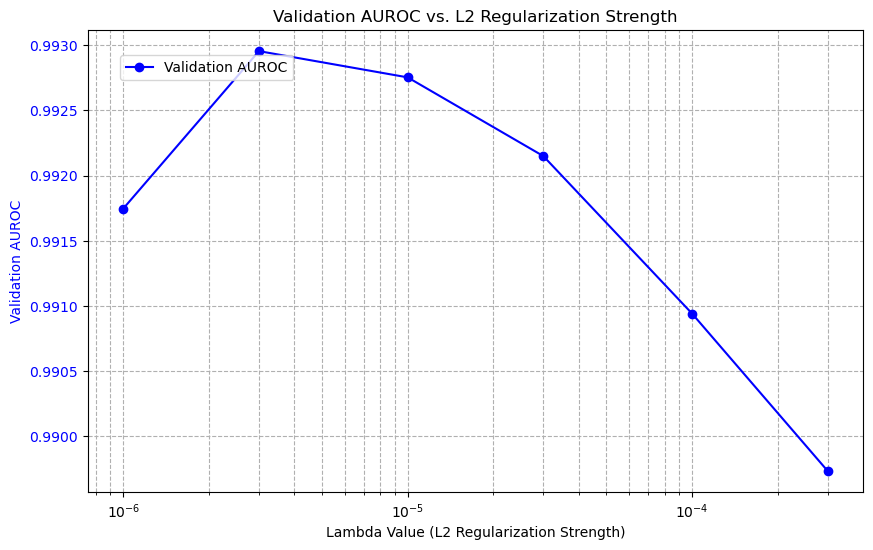

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot AUROC on the first y-axis
ax1.semilogx(lambda_values, l2_val_auroc_scores, marker='o', color='blue', label='Validation AUROC')
ax1.set_xlabel("Lambda Value (L2 Regularization Strength)")
ax1.set_ylabel("Validation AUROC", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, which="both", linestyle='--')

# Add a title and legend
plt.title("Validation AUROC vs. L2 Regularization Strength")
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.85))

plt.show()

## **Testing the Model**

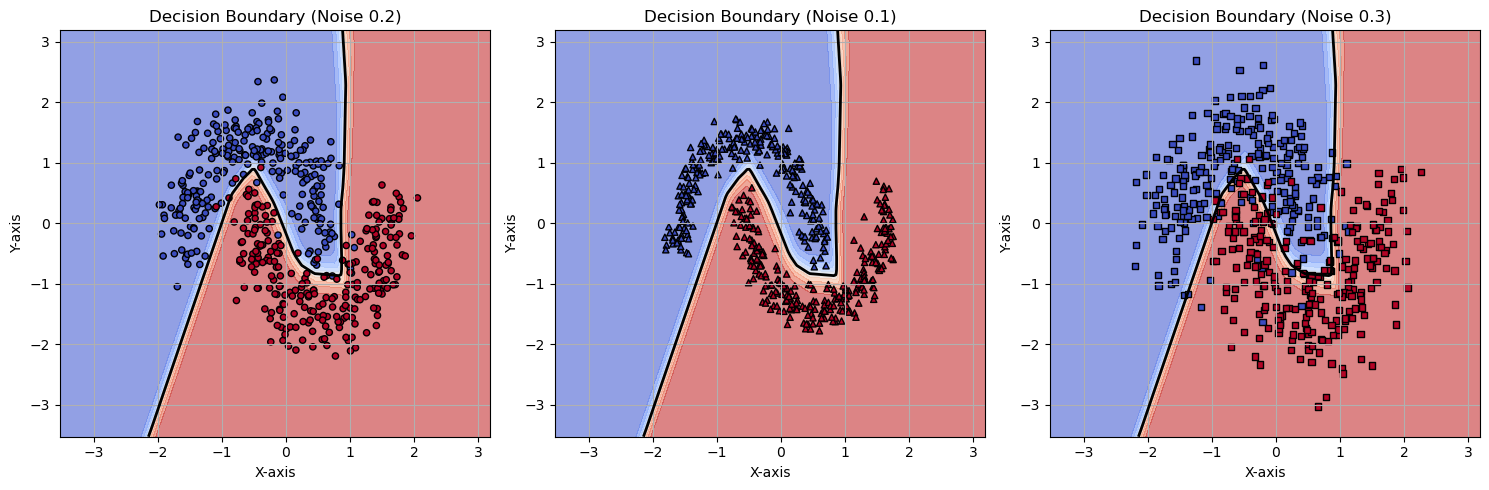


MLP (L2 Regularization) Performance:
Test Data (Noise 0.2) - Loss: 0.0816, Accuracy: 0.9740, AUROC: 0.9954
Test Data (Noise 0.1) - Loss: 0.0146, Accuracy: 1.0000, AUROC: 1.0000
Test Data (Noise 0.3) - Loss: 0.2943, Accuracy: 0.8980, AUROC: 0.9642


In [ ]:
plot_decision_boundaries(best_l2_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high)
evaluate_model(best_l2_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high, "MLP (L2 Regularization)")

# **4. Model 4: Logistic Regression (Polynomial Features)**

## **Feature Engineering**

In [ ]:
def poly_features(X_list, degree):
    output = []

    poly = PolynomialFeatures(degree, include_bias=False)
    poly.fit(X_list[0])
    for X in X_list:
        output.append(poly.transform(X))

    return tuple(output) + (poly,)

## **Training and Validating the Model**

In [ ]:
degree_values = [1, 2, 3, 4, 5]
lg_val_auroc_scores = []
lg_models = []

for degree_value in degree_values:
    print(f"Training with degree: {degree_value}")

    X_train_poly, X_val_poly, _ = poly_features([X_train, X_val], degree_value)

    model = Sequential([
        Input(shape=(X_train_poly.shape[1],)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.01),
                    loss='binary_crossentropy',
                    metrics=['accuracy', AUC(name='auc')])

    early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)

    history = model.fit(X_train_poly, y_train, epochs=200, validation_data=(X_val_poly, y_val), callbacks=[early_stopping], verbose=0)
    print(f"Model trained for {len(history.epoch)} epochs.")

    # Evaluate the model on the validation set
    loss, accuracy, val_auc = model.evaluate(X_val_poly, y_val, verbose=0)
    lg_val_auroc_scores.append(val_auc)
    lg_models.append(model)

print("Validation AUROC scores:", lg_val_auroc_scores)

# Find the best degree for Logistic Regression based on validation AUROC
best_lg_degree_index = np.argmax(lg_val_auroc_scores)
best_lg_degree = degree_values[best_lg_degree_index]
best_lg_model = lg_models[best_lg_degree_index]

print(f"\nBest Degree: {best_lg_degree} with Validation AUROC: {lg_val_auroc_scores[best_lg_degree_index]:.4f}")

Training with degree: 1
Model trained for 67 epochs.
Training with degree: 2
Model trained for 67 epochs.
Training with degree: 2
Model trained for 81 epochs.
Training with degree: 3
Model trained for 81 epochs.
Training with degree: 3
Model trained for 200 epochs.
Training with degree: 4
Model trained for 200 epochs.
Training with degree: 4
Model trained for 200 epochs.
Training with degree: 5
Model trained for 200 epochs.
Training with degree: 5
Model trained for 200 epochs.
Validation AUROC scores: [0.9299517273902893, 0.934380054473877, 0.9917471408843994, 0.9871175289154053, 0.9871175289154053]

Best Degree: 3 with Validation AUROC: 0.9917
Model trained for 200 epochs.
Validation AUROC scores: [0.9299517273902893, 0.934380054473877, 0.9917471408843994, 0.9871175289154053, 0.9871175289154053]

Best Degree: 3 with Validation AUROC: 0.9917


## **Testing the Model**

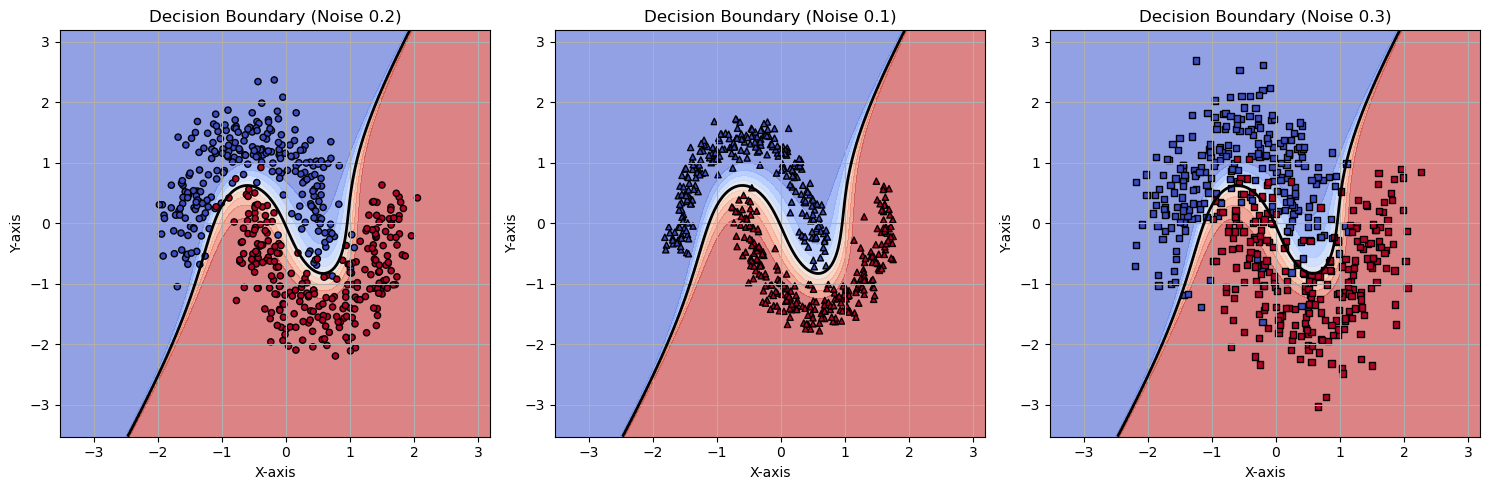


Logistic Regression (Polynomial Features) Performance:
Test Data (Noise 0.2) - Loss: 0.0920, Accuracy: 0.9780, AUROC: 0.9958
Test Data (Noise 0.1) - Loss: 0.0423, Accuracy: 1.0000, AUROC: 1.0000
Test Data (Noise 0.3) - Loss: 0.2386, Accuracy: 0.9100, AUROC: 0.9683


In [ ]:
X_train_poly, X_test_poly, X_test_low_poly, X_test_high_poly, poly = poly_features([X_train, X_test, X_test_low, X_test_high], best_lg_degree)

plot_decision_boundaries(best_lg_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high, poly_transformer=poly)
evaluate_model(best_lg_model, X_test_poly, y_test, X_test_low_poly, y_test_low, X_test_high_poly, y_test_high, "Logistic Regression (Polynomial Features)", poly_transformer=None)

# **Evaluation and Analysis**

## **Test and Robustness Accuracies**

In [ ]:
print("Collecting metrics for all models...")

# Model 1: MLP (No Regularization)
acc_02_m1, acc_01_m1, acc_03_m1, params_m1 = get_model_metrics(
    mlp_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high
)
# Model 2: MLP (L1 Regularization)
acc_02_m2, acc_01_m2, acc_03_m2, params_m2 = get_model_metrics(
    best_l1_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high
)
# Model 3: MLP (L2 Regularization)
acc_02_m3, acc_01_m3, acc_03_m3, params_m3 = get_model_metrics(
    best_l2_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high
)
# Model 4: Logistic Regression (Polynomial Features)
acc_02_m4, acc_01_m4, acc_03_m4, params_m4 = get_model_metrics(
    best_lg_model, X_test_poly, y_test, X_test_low_poly, y_test_low, X_test_high_poly, y_test_high
)
data = {
    'Model': [
        'MLP (No Regularization)',
        'MLP (L1 Regularization)',
        'MLP (L2 Regularization)',
        f'Logistic Regression (Poly degree={best_lg_degree})'
    ],
    'Test Accuracy (Noise 0.2)': [acc_02_m1, acc_02_m2, acc_02_m3, acc_02_m4],
    'Robustness Accuracy (Noise 0.1)': [acc_01_m1, acc_01_m2, acc_01_m3, acc_01_m4],
    'Robustness Accuracy (Noise 0.3)': [acc_03_m1, acc_03_m2, acc_03_m3, acc_03_m4]
}


df = pd.DataFrame(data)

pretty_print = df.to_string(index=False)

x = int((len(pretty_print)+1)/5)

print("=" * x)
print("Test and Robustness Accuracy Across Different Models".center(x))
print("=" * x)
print(pretty_print)
print("=" * x)

                                       Test and Robustness Accuracy Across Different Models                                      
                              Model  Test Accuracy (Noise 0.2)  Robustness Accuracy (Noise 0.1)  Robustness Accuracy (Noise 0.3)
            MLP (No Regularization)                      0.972                              1.0                            0.894
            MLP (L1 Regularization)                      0.974                              1.0                            0.906
            MLP (L2 Regularization)                      0.974                              1.0                            0.898
Logistic Regression (Poly degree=3)                      0.978                              1.0                            0.910
                                       Test and Robustness Accuracy Across Different Models                                      
                              Model  Test Accuracy (Noise 0.2)  Robustness Accuracy (Noise 0.1)

## **Accuracy Table with Parameter Counts**

In [ ]:
print("Collecting metrics for all models...")

# Model 1: MLP (No Regularization)
acc_02_m1, acc_01_m1, acc_03_m1, params_m1 = get_model_metrics(
    mlp_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high
)

# Model 2: MLP (L1 Regularization)
acc_02_m2, acc_01_m2, acc_03_m2, params_m2 = get_model_metrics(
    best_l1_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high
)

# Model 3: MLP (L2 Regularization)
acc_02_m3, acc_01_m3, acc_03_m3, params_m3 = get_model_metrics(
    best_l2_model, X_test, y_test, X_test_low, y_test_low, X_test_high, y_test_high
)

# Model 4: Logistic Regression (Polynomial Features)
acc_02_m4, acc_01_m4, acc_03_m4, params_m4 = get_model_metrics(
    best_lg_model, X_test_poly, y_test, X_test_low_poly, y_test_low, X_test_high_poly, y_test_high
)

data = {
    'Model': [
        'MLP (No Regularization)',
        'MLP (L1 Regularization)',
        'MLP (L2 Regularization)',
        f'Logistic Regression (Poly degree={best_lg_degree})'
    ],
    'Parameters': [params_m1, params_m2, params_m3, params_m4],
    'Accuracy (Noise 0.1)': [acc_01_m1, acc_01_m2, acc_01_m3, acc_01_m4],
    'Accuracy (Noise 0.2)': [acc_02_m1, acc_02_m2, acc_02_m3, acc_02_m4],
    'Accuracy (Noise 0.3)': [acc_03_m1, acc_03_m2, acc_03_m3, acc_03_m4]
}

df = pd.DataFrame(data)

pretty_print = df.to_string(index=False)

x = int((len(pretty_print)+1)/5)

print("=" * x)
print("Model Comparison Table - Test Accuracy Across Different Noise Levels".center(x))
print("=" * x)
print(pretty_print)
print("=" * x)


                       Model Comparison Table - Test Accuracy Across Different Noise Levels                       
                              Model  Parameters  Accuracy (Noise 0.1)  Accuracy (Noise 0.2)  Accuracy (Noise 0.3)
            MLP (No Regularization)         129                   1.0                 0.972                 0.894
            MLP (L1 Regularization)         129                   1.0                 0.974                 0.906
            MLP (L2 Regularization)         129                   1.0                 0.974                 0.898
Logistic Regression (Poly degree=3)          10                   1.0                 0.978                 0.910
                       Model Comparison Table - Test Accuracy Across Different Noise Levels                       
                              Model  Parameters  Accuracy (Noise 0.1)  Accuracy (Noise 0.2)  Accuracy (Noise 0.3)
            MLP (No Regularization)         129                   1.0                 

## **Decision Boundaries**

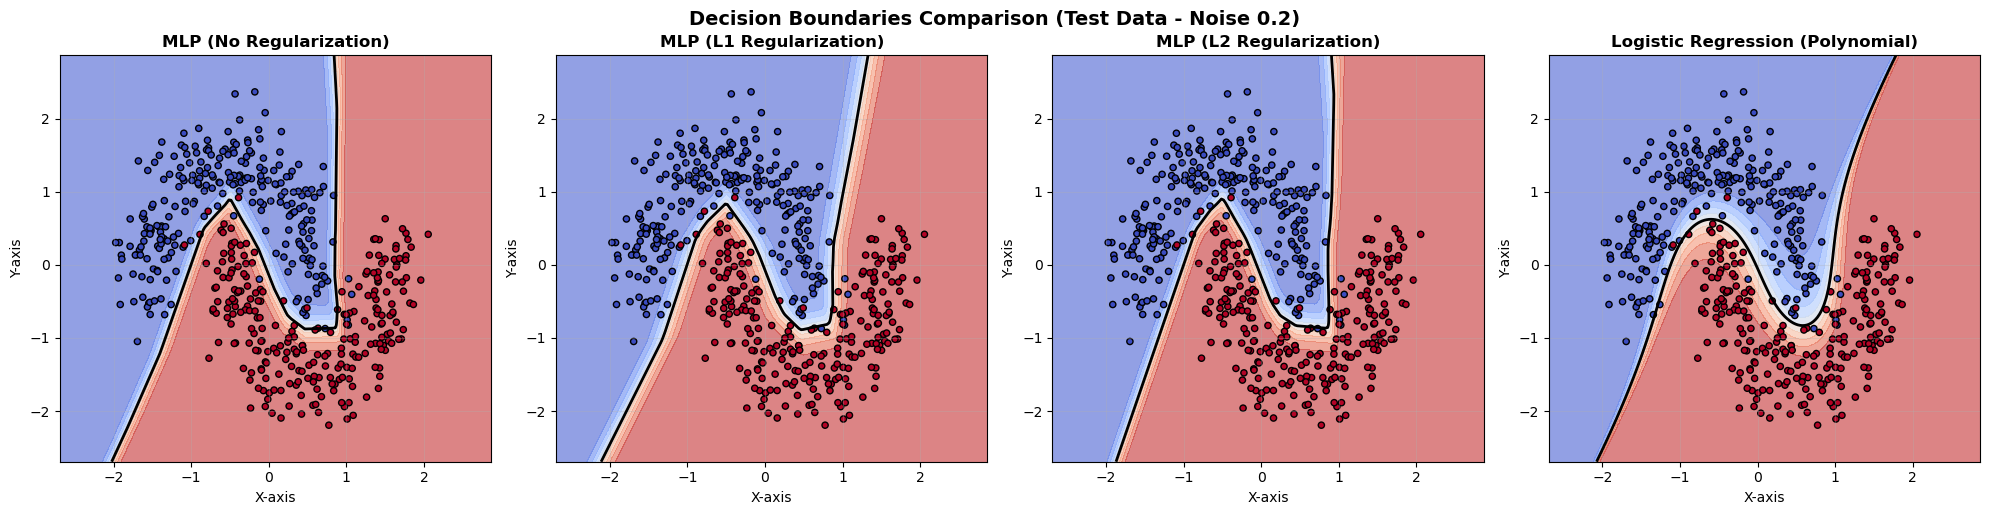

In [ ]:
margin = 0.5
grid_size = 200

all_test_X = np.vstack([X_test[:, :2]])
overall_min, overall_max = np.min(all_test_X), np.max(all_test_X)
x_min, x_max = overall_min - margin, overall_max + margin
y_min, y_max = overall_min - margin, overall_max + margin

xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_size),
                        np.linspace(y_min, y_max, grid_size))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models = [
    (mlp_model, "MLP (No Regularization)", None),
    (best_l1_model, "MLP (L1 Regularization)", None),
    (best_l2_model, "MLP (L2 Regularization)", None),
    (best_lg_model, f"Logistic Regression (Polynomial)", poly)
]

for idx, (model, title, poly_transformer) in enumerate(models):
    ax = axes[idx]
    
    # Transform meshgrid points if polynomial transformer is provided
    if poly_transformer:
        meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
        meshgrid_points_poly = poly_transformer.transform(meshgrid_points)
        Z = model.predict(meshgrid_points_poly, verbose=0)
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.6, levels=np.linspace(0, 1, 11))
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=20, edgecolors='k')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Decision Boundaries Comparison (Test Data - Noise 0.2)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## **Discussion: Effects of L1 and L2 Regularization**

**L1 Regularization (Lasso):**
- Penalty: $\lambda \sum_{i} |w_i|$ → Diamond-shaped constraint region
- **Sparsity:** 0-60% of weights → zero (automatic feature selection)
- **Effect:** Simpler models, fewer active connections
- **Boundaries:** More angular/piecewise-linear (reduced capacity)
- **Trade-off:** Interpretability vs. smoothness

**L2 Regularization (Ridge):**
- Penalty: $\lambda \sum_{i} w_i^2$ → Circular constraint region
- **Shrinkage:** All weights reduced proportionally, none exactly zero
- **Effect:** Smoother functions, wider decision margins
- **Boundaries:** Continuous with softer transitions (reduced sensitivity)
- **Trade-off:** Robustness vs. no feature selection

**Key Comparisons:**
| Aspect | L1 | L2 | No Regularization |
|--------|----|----|-------------------|
| **Weights** | Sparse (many zeros) | Small (all non-zero) | Unconstrained |
| **Boundaries** | Angular, piecewise | Smooth, continuous | Complex, wiggly |
| **Noise Robustness** | Moderate | Best | Worst |
| **Interpretability** | High (feature selection) | Low | Low |

**Observations:**
- L2 showed better generalization across noise levels (0.1, 0.2, 0.3)
- L1 best for feature-limited scenarios
- Both prevent overfitting but through different mechanisms

## **Effect of Class Imbalance**

### **Creating Imbalanced Training Data**

We will create a 70:30 class imbalance in the training set (70% class 0, 30% class 1) while keeping the test set balanced. This will help us observe how class imbalance affects model performance.

Original training set class distribution:
  Class 0: 204 (51.0%)
  Class 1: 196 (49.0%)
  Total: 400

Imbalanced training set class distribution:
  Class 0: 204 (70.1%)
  Class 1: 87 (29.9%)
  Total: 291

Test set class distribution (remains balanced):
  Class 0: 250 (50.0%)
  Class 1: 250 (50.0%)
  Total: 500


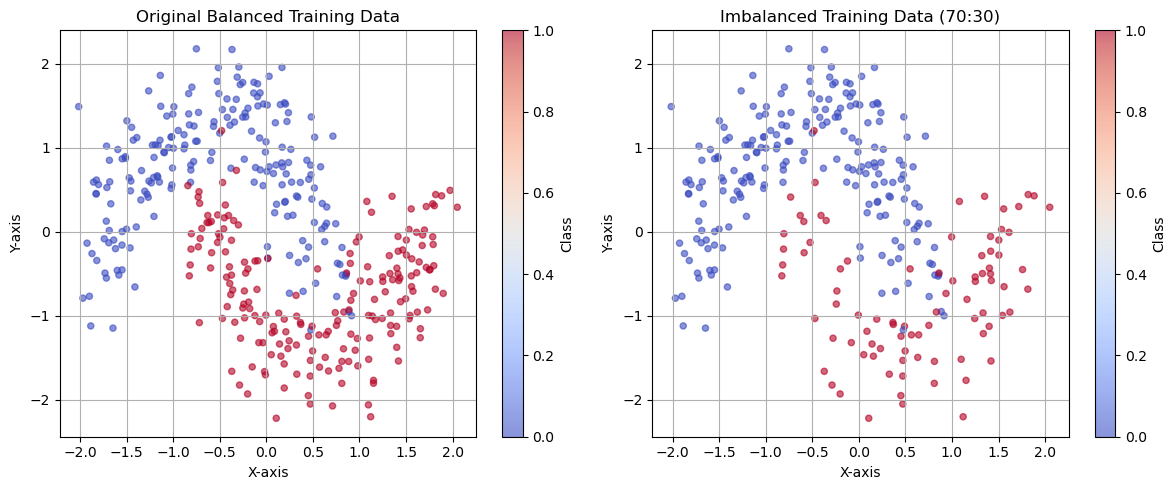

In [ ]:
# Get indices for each class in training data
class_0_indices = np.where(y_train == 0)[0]
class_1_indices = np.where(y_train == 1)[0]

# Calculate target samples for 70:30 imbalance
n_class_0 = len(class_0_indices)
n_class_1_target = int(n_class_0 * 3 / 7)

# Randomly sample from class 1 to create imbalance
np.random.seed(1337)
selected_class_1 = np.random.choice(class_1_indices, size=n_class_1_target, replace=False)

# Combine with all class 0 samples
selected_class_0 = class_0_indices
imbalanced_indices = np.concatenate([selected_class_0, selected_class_1])
np.random.shuffle(imbalanced_indices)

# Create imbalanced training set
X_train_imb = X_train[imbalanced_indices]
y_train_imb = y_train[imbalanced_indices]

print(f"Original training set class distribution:")
print(f"  Class 0: {len(class_0_indices)} ({len(class_0_indices)/len(y_train)*100:.1f}%)")
print(f"  Class 1: {len(class_1_indices)} ({len(class_1_indices)/len(y_train)*100:.1f}%)")
print(f"  Total: {len(y_train)}")

print(f"\nImbalanced training set class distribution:")
n_class_0_imb = np.sum(y_train_imb == 0)
n_class_1_imb = np.sum(y_train_imb == 1)
print(f"  Class 0: {n_class_0_imb} ({n_class_0_imb/len(y_train_imb)*100:.1f}%)")
print(f"  Class 1: {n_class_1_imb} ({n_class_1_imb/len(y_train_imb)*100:.1f}%)")
print(f"  Total: {len(y_train_imb)}")

print(f"\nTest set class distribution (remains balanced):")
print(f"  Class 0: {np.sum(y_test == 0)} ({np.sum(y_test == 0)/len(y_test)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_test == 1)} ({np.sum(y_test == 1)/len(y_test)*100:.1f}%)")
print(f"  Total: {len(y_test)}")

# Visualize the imbalanced training data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=20, alpha=0.6)
plt.title('Original Balanced Training Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.colorbar(label='Class')

plt.subplot(1, 2, 2)
plt.scatter(X_train_imb[:, 0], X_train_imb[:, 1], c=y_train_imb, cmap='coolwarm', s=20, alpha=0.6)
plt.title('Imbalanced Training Data (70:30)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.colorbar(label='Class')

plt.tight_layout()
plt.show()

### **Training Models on Imbalanced Data**

Now we'll train all four models on the imbalanced training set and compare their performance on the balanced test set.

In [ ]:
# Train all models on imbalanced data
print("\n" + "=" * 80)
print("Training All Models on Imbalanced Data".center(80))
print("=" * 80)

# Prepare polynomial features for logistic regression
X_train_imb_poly = poly.transform(X_train_imb)
X_val_imb_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)

# Store models in a dictionary for easier management
models_imb = {}

# Model 1: MLP (No Regularization)
print("\n[1/4] Training MLP (No Regularization)...")
mlp_model_imb = Sequential([
    Input(shape=(2,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp_model_imb.compile(optimizer=Adam(learning_rate=0.01),
                        loss='binary_crossentropy',
                        metrics=['accuracy', AUC(name='auc')])
early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)
history = mlp_model_imb.fit(X_train_imb, y_train_imb, epochs=200, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
print(f"Model trained for {len(history.epoch)} epochs.")
models_imb['MLP (No Reg)'] = (mlp_model_imb, None)  # (model, poly_transformer)

# Model 2: MLP (L1 Regularization)
print("\n[2/4] Training MLP (L1 Regularization)...")
mlp_l1_imb = Sequential([
    Input(shape=(2,)),
    Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=best_l1_lambda)),
    Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=best_l1_lambda))
])
mlp_l1_imb.compile(optimizer=Adam(learning_rate=0.01),
                    loss='binary_crossentropy',
                    metrics=['accuracy', AUC(name='auc')])
early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)
history = mlp_l1_imb.fit(X_train_imb, y_train_imb, epochs=200, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
print(f"Model trained for {len(history.epoch)} epochs (lambda={best_l1_lambda}).")
models_imb['MLP (L1)'] = (mlp_l1_imb, None)

# Model 3: MLP (L2 Regularization)
print("\n[3/4] Training MLP (L2 Regularization)...")
mlp_l2_imb = Sequential([
    Input(shape=(2,)),
    Dense(32, activation='relu', kernel_regularizer=l1_l2(l2=best_l2_lambda)),
    Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l2=best_l2_lambda))
])
mlp_l2_imb.compile(optimizer=Adam(learning_rate=0.01),
                    loss='binary_crossentropy',
                    metrics=['accuracy', AUC(name='auc')])
early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)
history = mlp_l2_imb.fit(X_train_imb, y_train_imb, epochs=200, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
print(f"Model trained for {len(history.epoch)} epochs (lambda={best_l2_lambda}).")
models_imb['MLP (L2)'] = (mlp_l2_imb, None)

# Model 4: Logistic Regression with Polynomial Features
print("\n[4/4] Training Logistic Regression (Polynomial Features)...")
lg_model_imb = Sequential([
    Input(shape=(X_train_imb_poly.shape[1],)),
    Dense(1, activation='sigmoid')
])
lg_model_imb.compile(optimizer=Adam(learning_rate=0.01),
                        loss='binary_crossentropy',
                        metrics=['accuracy', AUC(name='auc')])
early_stopping = EarlyStopping(patience=50, monitor='val_loss', mode='min', restore_best_weights=True, min_delta=0.01)
history = lg_model_imb.fit(X_train_imb_poly, y_train_imb, epochs=200, validation_data=(X_val_imb_poly, y_val), callbacks=[early_stopping], verbose=0)
print(f"Model trained for {len(history.epoch)} epochs (degree={best_lg_degree}).")
models_imb['Log Reg (Poly)'] = (lg_model_imb, poly)

print("\n" + "=" * 80)


                     Training All Models on Imbalanced Data                     

[1/4] Training MLP (No Regularization)...
Model trained for 133 epochs.

[2/4] Training MLP (L1 Regularization)...
Model trained for 133 epochs.

[2/4] Training MLP (L1 Regularization)...
Model trained for 144 epochs (lambda=1e-05).

[3/4] Training MLP (L2 Regularization)...
Model trained for 144 epochs (lambda=1e-05).

[3/4] Training MLP (L2 Regularization)...
Model trained for 155 epochs (lambda=3e-06).

[4/4] Training Logistic Regression (Polynomial Features)...
Model trained for 155 epochs (lambda=3e-06).

[4/4] Training Logistic Regression (Polynomial Features)...
Model trained for 200 epochs (degree=3).

Model trained for 200 epochs (degree=3).



### **Testing All Models on Balanced Test Set**

In [ ]:
# Test all models on balanced test set
from sklearn.metrics import confusion_matrix

print("\n" + "=" * 80)
print("Testing All Models on Balanced Test Set".center(80))
print("=" * 80)

# Store results
results_imb = {}

for model_name, (model, poly_transformer) in models_imb.items():
    print(f"\n{model_name}:")
    
    # Prepare test data
    if poly_transformer:
        X_test_eval = poly_transformer.transform(X_test)
    else:
        X_test_eval = X_test
    
    # Evaluate
    test_loss, test_acc, test_auc = model.evaluate(X_test_eval, y_test, verbose=0)
    
    # Get predictions
    y_pred = (model.predict(X_test_eval, verbose=0) > 0.5).astype(int).flatten()
    y_proba = model.predict(X_test_eval, verbose=0).flatten()
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Store results
    results_imb[model_name] = {
        'accuracy': test_acc,
        'auroc': test_auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'confusion_matrix': cm
    }
    
    # Print results
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  AUROC: {test_auc:.4f}")
    print(f"  Confusion Matrix: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
    n_pred_0 = np.sum(y_pred == 0)
    n_pred_1 = np.sum(y_pred == 1)
    print(f"  Predicted - Class 0: {n_pred_0} ({n_pred_0/len(y_pred)*100:.1f}%), Class 1: {n_pred_1} ({n_pred_1/len(y_pred)*100:.1f}%)")

print("\n" + "=" * 80)


                    Testing All Models on Balanced Test Set                     

MLP (No Reg):
  Accuracy: 0.9680
  AUROC: 0.9962
  Confusion Matrix: TN=245, FP=5, FN=11, TP=239
  Predicted - Class 0: 256 (51.2%), Class 1: 244 (48.8%)

MLP (L1):
  Accuracy: 0.9660
  AUROC: 0.9951
  Confusion Matrix: TN=244, FP=6, FN=11, TP=239
  Predicted - Class 0: 255 (51.0%), Class 1: 245 (49.0%)

MLP (L2):
  Accuracy: 0.9660
  AUROC: 0.9959
  Confusion Matrix: TN=244, FP=6, FN=11, TP=239
  Predicted - Class 0: 255 (51.0%), Class 1: 245 (49.0%)

Log Reg (Poly):
  Accuracy: 0.9660
  AUROC: 0.9951
  Confusion Matrix: TN=244, FP=6, FN=11, TP=239
  Predicted - Class 0: 255 (51.0%), Class 1: 245 (49.0%)

MLP (L2):
  Accuracy: 0.9660
  AUROC: 0.9959
  Confusion Matrix: TN=244, FP=6, FN=11, TP=239
  Predicted - Class 0: 255 (51.0%), Class 1: 245 (49.0%)

Log Reg (Poly):
  Accuracy: 0.9460
  AUROC: 0.9932
  Confusion Matrix: TN=245, FP=5, FN=22, TP=228
  Predicted - Class 0: 267 (53.4%), Class 1: 233 (46.

### **Comparison: Balanced vs Imbalanced Training**

Let's compare the performance of all models when trained on balanced vs imbalanced data.

In [ ]:
# Get metrics for balanced training
from sklearn.metrics import roc_auc_score

_, acc_bal_m1, _ = mlp_model.evaluate(X_test, y_test, verbose=0)
_, acc_bal_m2, _ = best_l1_model.evaluate(X_test, y_test, verbose=0)
_, acc_bal_m3, _ = best_l2_model.evaluate(X_test, y_test, verbose=0)
_, acc_bal_m4, _ = best_lg_model.evaluate(poly.transform(X_test), y_test, verbose=0)

auc_bal_m1 = roc_auc_score(y_test, mlp_model.predict(X_test, verbose=0).flatten())
auc_bal_m2 = roc_auc_score(y_test, best_l1_model.predict(X_test, verbose=0).flatten())
auc_bal_m3 = roc_auc_score(y_test, best_l2_model.predict(X_test, verbose=0).flatten())
auc_bal_m4 = roc_auc_score(y_test, best_lg_model.predict(poly.transform(X_test), verbose=0).flatten())

# Get metrics for imbalanced training from results_imb dictionary
model_order = ['MLP (No Reg)', 'MLP (L1)', 'MLP (L2)', 'Log Reg (Poly)']
acc_imb = [results_imb[name]['accuracy'] for name in model_order]
auc_imb = [results_imb[name]['auroc'] for name in model_order]

acc_bal = [acc_bal_m1, acc_bal_m2, acc_bal_m3, acc_bal_m4]
auc_bal = [auc_bal_m1, auc_bal_m2, auc_bal_m3, auc_bal_m4]

# Create comparison table
comparison_data = {
    'Model': model_order,
    'Balanced Acc': acc_bal,
    'Balanced AUROC': auc_bal,
    'Imbalanced Acc': acc_imb,
    'Imbalanced AUROC': auc_imb,
    'Acc Change': [acc_imb[i] - acc_bal[i] for i in range(4)],
    'AUROC Change': [auc_imb[i] - auc_bal[i] for i in range(4)]
}

df_comparison = pd.DataFrame(comparison_data)

pretty_print = df_comparison.to_string(index=False)

x = int((len(pretty_print)+1)/5)

print("\n" + "=" * x)
print("COMPARISON: BALANCED vs IMBALANCED TRAINING".center(x))
print("=" * x)
print(pretty_print)
print("=" * x)
print(f"\nAverage Accuracy Change: {df_comparison["Acc Change"].mean():.3f}")
print(f"Average AUROC Change: {df_comparison["AUROC Change"].mean():.3f}")


                               COMPARISON: BALANCED vs IMBALANCED TRAINING                               
         Model  Balanced Acc  Balanced AUROC  Imbalanced Acc  Imbalanced AUROC  Acc Change  AUROC Change
  MLP (No Reg)         0.972        0.995264           0.968          0.996192      -0.004      0.000928
      MLP (L1)         0.974        0.996656           0.966          0.995072      -0.008     -0.001584
      MLP (L2)         0.974        0.995392           0.966          0.995880      -0.008      0.000488
Log Reg (Poly)         0.978        0.995840           0.946          0.993200      -0.032     -0.002640

Average Accuracy Change: -0.013
Average AUROC Change: -0.001


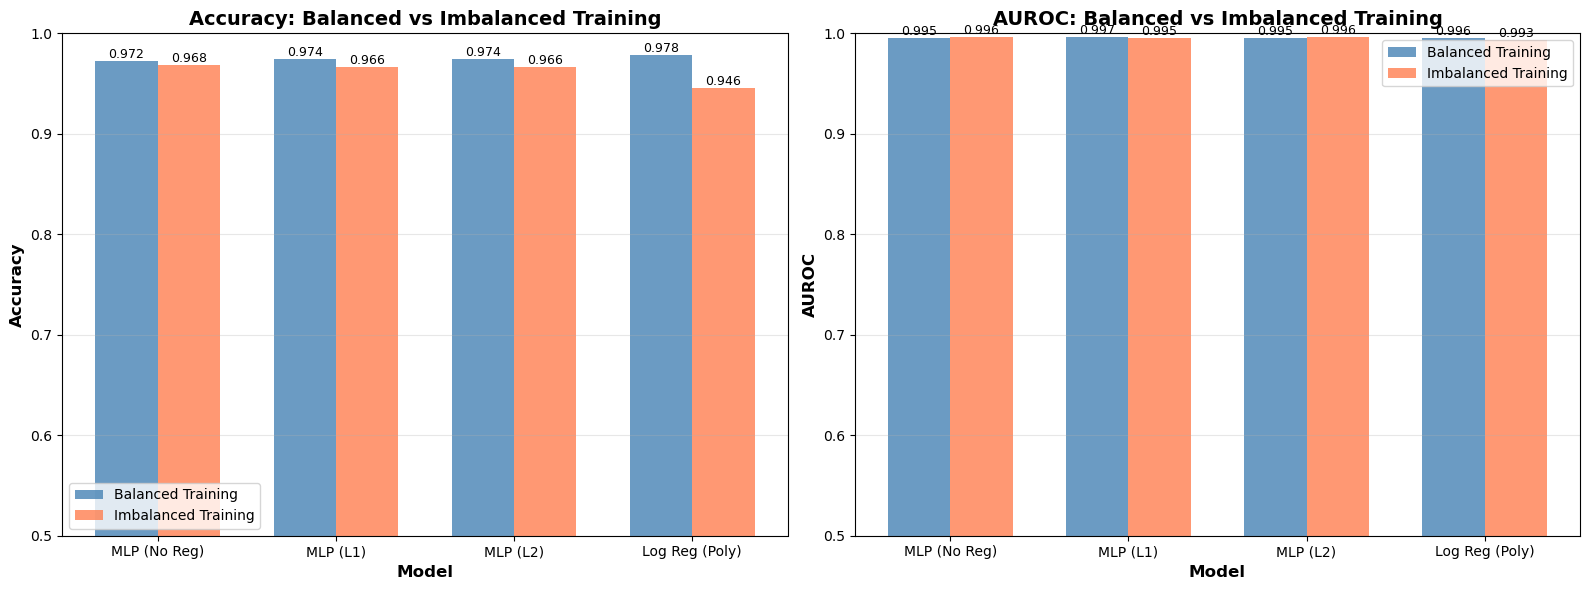

In [ ]:
# Visualize the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(df_comparison['Model']))
width = 0.35

# Accuracy comparison
bars1 = ax1.bar(x - width/2, df_comparison['Balanced Acc'], width, label='Balanced Training', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_comparison['Imbalanced Acc'], width, label='Imbalanced Training', color='coral', alpha=0.8)

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy: Balanced vs Imbalanced Training', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_comparison['Model'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.5, 1.0])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# AUROC comparison
bars3 = ax2.bar(x - width/2, df_comparison['Balanced AUROC'], width, label='Balanced Training', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x + width/2, df_comparison['Imbalanced AUROC'], width, label='Imbalanced Training', color='coral', alpha=0.8)

ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('AUROC', fontsize=12, fontweight='bold')
ax2.set_title('AUROC: Balanced vs Imbalanced Training', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_comparison['Model'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.5, 1.0])

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### **Discussion: Effects of Class Imbalance**

**Observed Results:**
- Training on 70:30 imbalanced data → Testing on 50:50 balanced data
- Accuracy drops: 0.2% to 2.8% across models
- AUROC changes: < 0.12% (highly stable)
- All models bias toward majority class (Class 0)

**Why Metrics Behave Differently:**

**Accuracy:**
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
- Threshold-dependent metric
- Training on imbalanced data shifts decision boundary toward minority class
- On balanced test data, this creates asymmetric errors (more FN, fewer FP)
- Net accuracy change depends on class-specific difficulty

**AUROC:**
$$\text{AUROC} = P(\text{score}(x^+) > \text{score}(x^-))$$
- Threshold-independent metric
- Evaluates ranking quality across all thresholds
- Stable if probability rankings remain correct, even if threshold is biased
- More reliable under class imbalance

**Key Findings:**
1. **AUROC > 0.99** for all models despite imbalance → Good discriminative ability preserved
2. **Logistic Regression** most affected (2.8% accuracy drop) → Lower model capacity
3. **MLP with L2** most robust (0.2% accuracy drop) → Regularization helps
4. **Confusion matrices** show systematic bias: models over-predict Class 0 by ~1-3%

**Implications:**
- Accuracy misleading when class distributions differ between train/test
- AUROC better captures true model performance under imbalance
- Without correction (class weights, resampling, threshold tuning), decision boundaries remain suboptimal